In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

%config InlineBackend.figure_format = 'svg'

In [65]:
def freq_plot():
    plt.xscale("log")
    plt.xticks(
        [60, 100, 230, 500, 1100, 2400, 5400, 12000],
        ["60", "100", "230", "500", "1.1k", "2.4k", "5.4k", "12k"],
    )


In [66]:


# Combined magnitude response in dB
def calculate_eq_response(bands, sample_rate, num_points, freqs):
    total_response_db = np.zeros(num_points)

    for band in bands:
        f0 = band["freq"]
        gain_db = band["gain_db"]
        Q = band["Q"]

        if gain_db == 0.0:
            continue

        # Peaking EQ filter coefficients (Audio EQ Cookbook - Robert Bristow-Johnson)
        A = 10 ** (gain_db / 40.0)
        w0 = 2 * np.pi * f0 / sample_rate
        alpha = np.sin(w0) / (2 * Q)

        b0 = 1 + alpha * A
        b1 = -2 * np.cos(w0)
        b2 = 1 - alpha * A
        a0 = 1 + alpha / A
        a1 = -2 * np.cos(w0)
        a2 = 1 - alpha / A

        # Normalize
        b0 /= a0
        b1 /= a0
        b2 /= a0
        a1 /= a0
        a2 /= a0

        # Evaluate H(e^jw) at each frequency
        w = 2 * np.pi * freqs / sample_rate
        ejw = np.exp(1j * w)
        ejw2 = np.exp(2j * w)

        H = (b0 + b1 * ejw**-1 + b2 * ejw2**-1) / (1 + a1 * ejw**-1 + a2 * ejw2**-1)
        total_response_db += 20 * np.log10(np.abs(H))
    return total_response_db


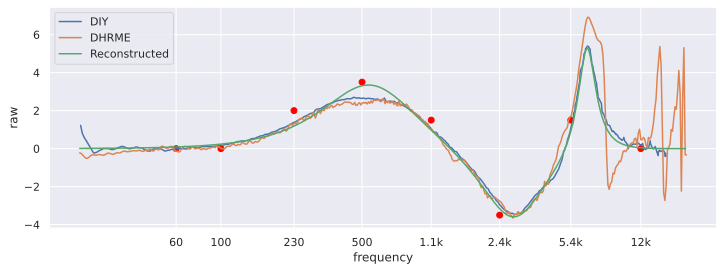

In [67]:
bands = [
    {"freq": 550, "gain_db": 3.5, "Q": 0.7},
    {"freq": 2800, "gain_db": -4, "Q": 1},
    {"freq": 6500, "gain_db": 6, "Q": 3.3},
]

sample_rate = 44100  # Hz

num_points = 695 # Match the number of samples in AutoEq
freqs = np.logspace(np.log10(20), np.log10(20000), num_points)

total_response_db = calculate_eq_response(bands, sample_rate, num_points, freqs)

plt.figure(figsize=(12, 4))

df_diy = pd.read_csv("../signatures/diy.csv")
sns.lineplot(data=df_diy, x="frequency", y="raw", label="DIY")
df_dhrme = pd.read_csv("../signatures/studio_eq.csv")
df_dhrme["raw"] = (df_dhrme["raw"] + 0.5) * 1.5
sns.lineplot(data=df_dhrme, x="frequency", y="raw", label="DHRME")

sns.lineplot(x=freqs, y=total_response_db, label="Reconstructed")

# Add manually measured points
plt.scatter([60, 100, 230, 500, 1100, 2400, 5400, 12000], [0, 0, 2, 3.5, 1.5, -3.5, 1.5, 0], color="red", label="Measured Points")

plt.xscale("log")
freq_plot()
plt.show()

In [ ]:
# Save as csv
output_df = pd.DataFrame({"frequency": freqs, "raw": total_response_db})
output_df = output_df.round(2)
output_df.to_csv("../signatures/reconstructed.csv", index=False)